# Python Bootcamp Day 4

## Multi-dimensional data with xarray (continued)



# TODO: ADD Kara's edits here

### 2.4 Manipulating multi-dimensional arrays

Tools we will use:
* `slice`
* `mean`
* `sum`
* `groupby`

For more information on xarray tools: http://xarray.pydata.org/en/stable/user-guide/index.html
<br/>For more information on xarray indexing: http://xarray.pydata.org/en/stable/user-guide/indexing.html

For convenience, we will store the precipitation data as it's own data array.

Notice that we are sub-selecting an xarray DataArray from an xarray Dataset

In [ ]:
precip = ds.precip
precip

### `slice` and `mean` Example 

We can use `slice` to select only a small portion of the data.

Why use `slice`? So that it is faster and easier to deal with. For instance, if you had 1 million data points for each year from the year 2010 - 2020 (so, total of 10 million data points), and you were only interested in the year 2004, you can use `slice` to select the year 2004 data to work on.

We can use `.mean` to average the data. Let's look at the average precipitation in 1995.

**Goal**: select 1995 dates, January to December, and take the mean over the dimension of `time`, then plot the result.

Let's do this step-by-step. The last line of the code cell below is a concise way of combining multiple operations in one line. Which do you prefer? And why?

In [ ]:
# Step 1: select the time slice for 1995 and store it in a new variable called `precip_1995`
precip_1995 = precip.sel(time=slice('1995-01-01','1995-12-01'))

# Step 2: take the mean over the dimension of `time` and store it in a new variable called `precip_1995_mean`
precip_1995_mean = precip_1995.mean(dim='time')

# Step 3: plot the mean precipitation for 1995 and store the plot in a variable called `precip_1995_plot`
precip_1995_plot = precip_1995_mean.plot()

### alternative code that does the same thing but is more concise:
# notice how we can chain the operations together without needing to create intermediate variables
precip_1995_plot = precip.sel(time=slice('1995-01-01','1995-12-01')).mean(dim='time').plot()

### `groupby` Example 

`.groupby` is another useful tool. It allows us to split the data into multiple groups, work within these groups, and combine them back into a single dataset. Let's group time by season:

In [ ]:
precip.groupby('time.season')

The data has been divided into four seasons: 

'DJF' for December-January-February (winter)

'JJA' for June-July-August (summer)

'MAM' for March-April-May (spring)

'SON' for September-October-November (fall). 

These are common shorthand notations used in Earth science.

Using `.sum`, we can sum over a given dimension. Combining groupby and sum, we can calculate the weighted seasonal averages. Let's just pick one year and one grid for simplicity. The equation below shows an example on how to calculate the weighted averaged preipitation for spring (MAM).

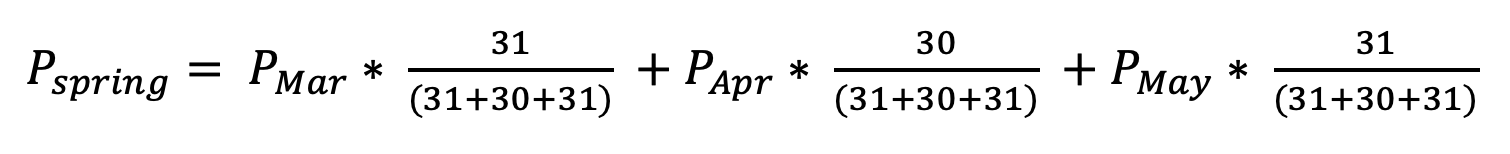

Step 1: Identify a time period and location of interest

In [ ]:
# select the time slice for 1995, then select the latitude of 1.25 and longitude of 72, and store the result in a new variable called `precip_example`
precip_example = precip.sel(time=slice('1995-01-01','1995-12-01')).sel(lat=1.25).sel(lon=72)

In [ ]:
month_length = precip_example.time.dt.days_in_month
month_length

In [ ]:
# Calculate the weights by grouping by 'time.season'
weights = month_length.groupby('time.season') / month_length.groupby('time.season').sum() # divide by sum to normalize the weights

# Calculate the weighted average by multiplying the original data by the weights and then summing over the 'time' dimension
precip_weighted = (precip_example * weights).groupby('time.season').sum(dim='time')
precip_weighted

In [ ]:
# Compared with unweighted seasonal averages
precip_unweighted = precip_example.groupby('time.season').mean(dim='time')
precip_unweighted

<span style="color:blue"> Plot the sum of precipitation over March, April, and May of 2005. </span><br>

### 2.5 Xarray to numpy

Once again, numpy is a powerful tool. Therefore, it is to our benefit to be able to convert xarray datasets to numpy arrays. 
<br/> We can do this with `np.array()`.

In [ ]:
lat    = np.array(ds['lat'])
lon    = np.array(ds['lon'])
time   = np.array(ds['time'])
precip = np.array(ds['precip'])
lat

As seen above, Xarray introduces labels on top of raw NumPy-like multidimensional arrays, which allows for a more intuitive, more concise, and less error-prone developer experience. For example, with label names, you’ll easily understand what you were thinking when you come back to look at your code weeks or months later.

Notice also how numpy requires you to create an individual variable for each of the data categories while xarray allowed you to use a single dataset where all the data was self-contained.

Xarray also allows you to convert it to different formats using other ways.

<span style="color:blue"> See what happens when you use `.values` and `.data` (Example: `ds['precip].values`) </span><br>

### 2.6 Xarray to pandas

Xarray and pandas objects are also interchangeable. A shortcut to convert a dataArray directly into a pandas object is  `DataArray.to_pandas()` (i.e., a 1D array is converted to a `Series`, 2D to `DataFrame` and 3D to `Panel`).

In [ ]:
# For example, from a 2D array with dimensions lat and lon
df = fname['precip'].sel(time='1995-01-01').to_pandas()
df

Xarray is heavily inspired by pandas, which also works with labeled arrays, and it uses pandas internally. The main distinguishing feature of xarray's dataarray over labeled arrays in pandas is that dimensions can have names (e.g. "time", "latitude"), which are easier to keep track of than axis numbers. While pandas is a great tool for working with tabular data, it can get a little awkward when data is of higher dimension (See more at https://xarray.pydata.org/en/v0.9.2/faq.html). Also, `Panel` (for 3D data in pandas) has been removed since version 0.25.0 in 2019. So, if the data is multi-dimensional, xarray will be a better tool.

### 2.7: Breakout Room Activity

We will be looking at Northern Hemisphere snowcover data.

 <font color='blue'> Load in the snowcover data using xarray. </font>

 <font color='blue'> Look at the file. </font>

 <font color='blue'> Use .sel to plot a map of snowcover on September 1, 1978. </font>

 <font color='blue'> Use .sel, slice, and .mean to plot the average snowcover in the 1980s. </font>